# SLSN Multi-Model Comparison Notebook

Cross-model analysis across all 3 rate models × 4 cadences.
Loads from saved summary CSVs, `.npy` metric arrays, and population pickles — **no rerunning metrics**.

## Structure
- **Cell 1**: Setup, paths, and configuration
- **Cell 2**: Load all 3 summary CSVs → combined DataFrame
- **Cell 3**: Summary table (detections/yr, efficiency — all 12 combos)
- **Cell 4**: Bar chart — detections/yr by cadence, grouped by model (Detect metric)
- **Cell 5**: Bar chart — all 3 metrics side by side (Detect / Characterize / SpecTrigger)
- **Cell 6**: Load populations + .npy arrays for z-bin analysis
- **Cell 7**: Adam's z-bins: efficiency vs redshift for all 3 models × baseline cadence
- **Cell 8**: Adam's fixed bins z=1.3–1.7: table of detections + efficiency per model
- **Cell 9**: HEALPix sky map — Detect efficiency, fe_dependent × baseline (reference)

## Reload flags
- **Templates**: NO reload — only loaded in Cell 6 to support population loading
- **Population**: NO reload — loading from existing PKL files
- **Mag grid**: NO reload
- **Kernel restart**: Only if you edit a `.py` module and need `reload()` to pick it up

In [1]:
# ============================================================================
# CELL 1: Setup and configuration
# ============================================================================
import sys, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import healpy as hp
from pathlib import Path
from importlib import reload

# --- Repo path ---
REPO = Path('/users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric')
sys.path.insert(0, str(REPO / 'py_files'))
from slsn_metrics.paths import get_shared_output_dir, get_output_dir, get_rate_csv_path
import slsn_metrics.diagnostics as diag_mod
reload(diag_mod)
from slsn_metrics.diagnostics import (
    plot_population_rate_vs_redshift,
    plot_healpix_efficiency,
)

# --- Configuration ---
# These are the 260407 production runs — use these files
MODELS   = ['fe_dependent', 'o_dependent', 'naive']
CADENCES = [
    'baseline_v5.1.1_10yrs',
    'four_roll_v5.0.0_10yrs',
    'noroll_v5.0.0_10yrs',
    'poor_weather_v5.0.1_10yrs',
]
DATE_TAG     = '260407'    # ← production run date stamp
SURVEY_YEARS = 10
Z_MIN, Z_MAX = 0.1, 2.0
MJD0         = 60980.5

# --- Paths ---
SHARED_DIR = get_shared_output_dir('SLSNe')

# --- Verify summary CSVs exist ---
# These are the all-cadence combined CSVs written by run_slsn_multi_metrics_parallel
print('=== Summary CSV Check ===')
SUMMARY_FILES = {}
for model in MODELS:
    model_dir = get_output_dir('SLSNe', subdir=model)
    # Combined all-cadence summary file (one per model, written at end of parallel run)
    matches = sorted(model_dir.glob(f'summary_{model}_all_cadences_z{Z_MIN}-{Z_MAX}_{DATE_TAG}.csv'))
    if matches:
        SUMMARY_FILES[model] = matches[-1]
        print(f'  OK  {model}: {matches[-1].name}')
    else:
        print(f'  MISSING  {model}: expected summary_{model}_all_cadences_z{Z_MIN}-{Z_MAX}_{DATE_TAG}.csv')

print(f'\nFound {len(SUMMARY_FILES)}/3 summary files')

=== Summary CSV Check ===
  OK  fe_dependent: summary_fe_dependent_all_cadences_z0.1-2.0_260407.csv
  OK  o_dependent: summary_o_dependent_all_cadences_z0.1-2.0_260407.csv
  OK  naive: summary_naive_all_cadences_z0.1-2.0_260407.csv

Found 3/3 summary files


In [2]:
# ============================================================================
# CELL 2: Load all 3 summary CSVs into one combined DataFrame
# Each CSV has columns: cadence, metric, n_events, n_success, efficiency
# We add a 'model' column and compute 'per_year'
# ============================================================================
rows = []
for model, csv_path in SUMMARY_FILES.items():
    df_s = pd.read_csv(csv_path)
    df_s['model']    = model
    df_s['per_year'] = df_s['n_success'] / SURVEY_YEARS
    rows.append(df_s)

df_all = pd.concat(rows, ignore_index=True)

# Clean up cadence names for display (strip version/10yrs suffix)
cadence_labels = {
    'baseline_v5.1.1_10yrs':    'baseline',
    'four_roll_v5.0.0_10yrs':   'four_roll',
    'noroll_v5.0.0_10yrs':      'noroll',
    'poor_weather_v5.0.1_10yrs':'poor_weather',
}
df_all['cadence_short'] = df_all['cadence'].map(cadence_labels)

model_labels = {
    'fe_dependent': 'Fe-dependent',
    'o_dependent':  'O-dependent',
    'naive':        'Naive SFR',
}
df_all['model_label'] = df_all['model'].map(model_labels)

print(f'Loaded {len(df_all)} rows across {df_all["model"].nunique()} models')
print(f'Metrics present: {df_all["metric"].unique().tolist()}')

Loaded 36 rows across 3 models
Metrics present: ['SLSN_Detect_Metric', 'SLSN_CharacterizeMetric', 'SLSN_SpecTriggerMetric']


In [3]:
detect_df = df_all[df_all['metric'] == 'SLSN_Detect_Metric'].copy()
char_df   = df_all[df_all['metric'] == 'SLSN_CharacterizeMetric'].copy()
spec_df   = df_all[df_all['metric'] == 'SLSN_SpecTriggerMetric'].copy()

# Detections per year — pivot: rows=model, columns=cadence
pivot_per_yr = detect_df.pivot_table(
    index='model_label', columns='cadence_short',
    values='per_year', aggfunc='first'
)[['baseline', 'four_roll', 'noroll', 'poor_weather']]

# Efficiency [%] pivot
pivot_eff = detect_df.pivot_table(
    index='model_label', columns='cadence_short',
    values='efficiency', aggfunc='first'
)[['baseline', 'four_roll', 'noroll', 'poor_weather']] * 100

print('=== Detections per Year (Detect Metric) — 3 models × 4 cadences ===')
print(pivot_per_yr.round(0).to_string())

print('\n=== Detection Efficiency [%] ===')
print(pivot_eff.round(3).to_string())

# Population sizes for context
print('\n=== Population sizes (n_events) ===')
for model in MODELS:
    n = detect_df[detect_df['model'] == model]['n_events'].iloc[0]
    print(f'  {model:<15}: {n:>9,} events')

=== Detections per Year (Detect Metric) — 3 models × 4 cadences ===
cadence_short  baseline  four_roll  noroll  poor_weather
model_label                                             
Fe-dependent      642.0      638.0   730.0         488.0
Naive SFR         330.0      325.0   378.0         254.0
O-dependent       386.0      379.0   443.0         293.0

=== Detection Efficiency [%] ===
cadence_short  baseline  four_roll  noroll  poor_weather
model_label                                             
Fe-dependent      0.286      0.284   0.325         0.218
Naive SFR         0.440      0.433   0.504         0.338
O-dependent       0.337      0.331   0.386         0.256

=== Population sizes (n_events) ===
  fe_dependent   : 2,243,377 events
  o_dependent    : 1,146,435 events
  naive          :   750,598 events


Saved: multimodel_detections_per_yr_260407.png


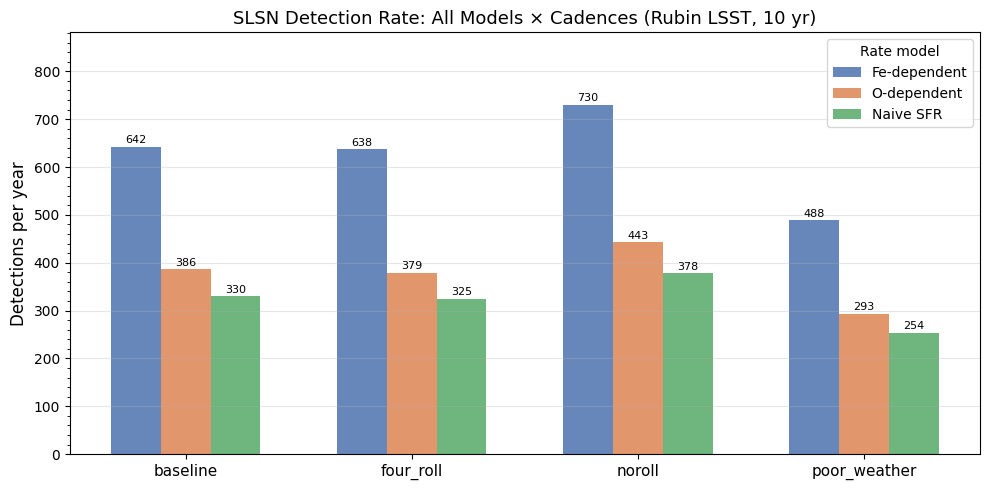

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

cadence_order = ['baseline', 'four_roll', 'noroll', 'poor_weather']
model_order   = ['Fe-dependent', 'O-dependent', 'Naive SFR']
colors        = ['#4C72B0', '#DD8452', '#55A868']  # blue, orange, green

n_cadences = len(cadence_order)
n_models   = len(model_order)
width      = 0.22
x          = np.arange(n_cadences)

for i, (model_label, color) in enumerate(zip(model_order, colors)):
    vals = []
    for cad in cadence_order:
        row = detect_df[
            (detect_df['model_label'] == model_label) &
            (detect_df['cadence_short'] == cad)
        ]
        vals.append(row['per_year'].values[0] if len(row) else 0)
    offset = (i - (n_models - 1) / 2) * width
    bars = ax.bar(x + offset, vals, width, label=model_label, color=color, alpha=0.85)
    # Label each bar with its value
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                f'{v:.0f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(cadence_order, fontsize=11)
ax.set_ylabel('Detections per year', fontsize=12)
ax.set_title('SLSN Detection Rate: All Models × Cadences (Rubin LSST, 10 yr)', fontsize=13)
ax.legend(title='Rate model', fontsize=10)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)  # headroom for labels
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
out_fig = get_output_dir('SLSNe') / f'multimodel_detections_per_yr_{DATE_TAG}.png'
plt.savefig(out_fig, dpi=150)
print(f'Saved: {out_fig.name}')
plt.show()

Saved: multimodel_all_metrics_all_cadences_260407.png


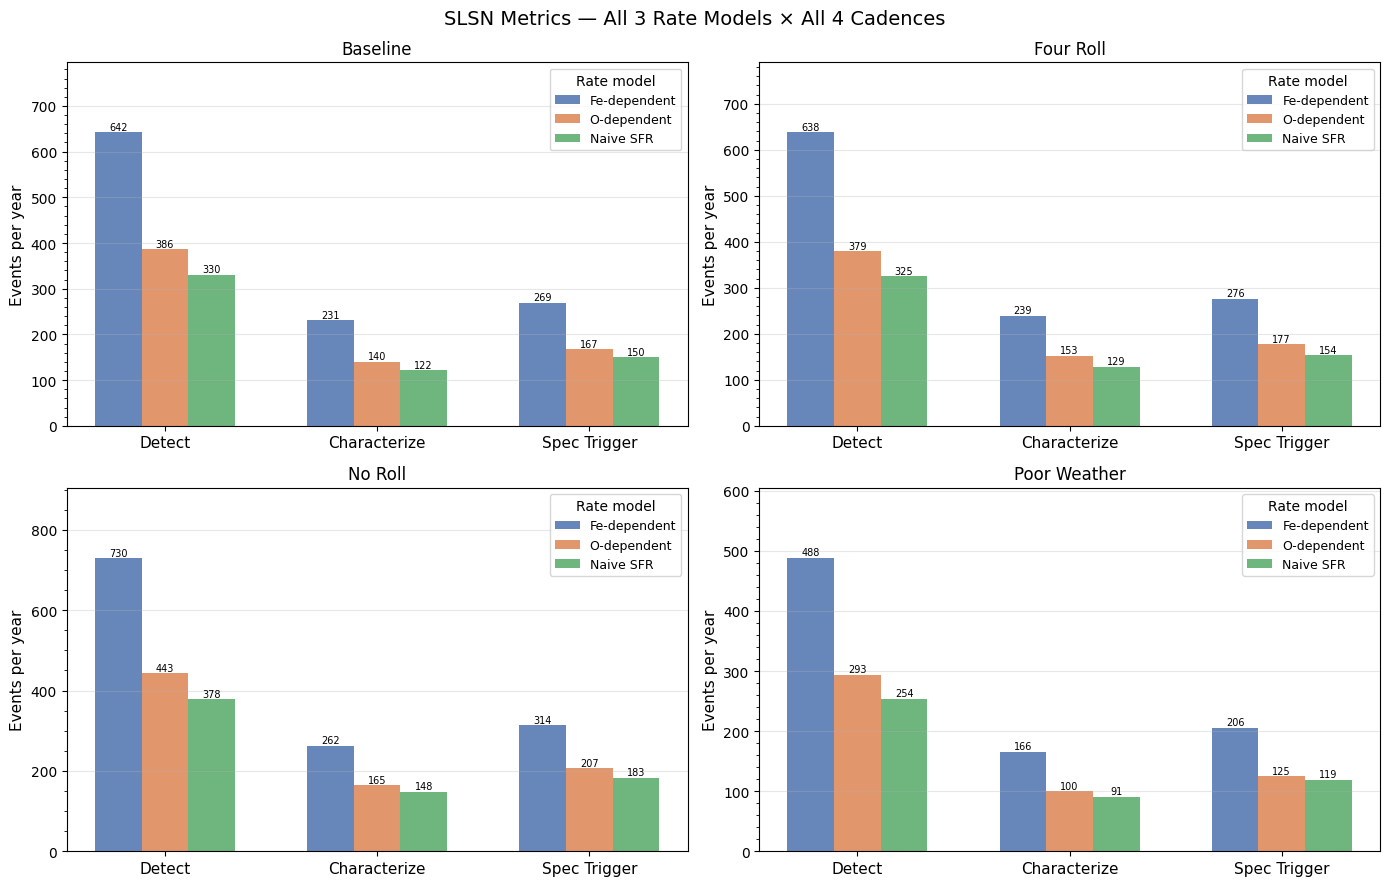

In [5]:
# ============================================================================
# CELL 5: All 3 metrics side by side — all 4 cadences
# 2×2 grid: one panel per cadence, each showing Detect / Characterize / SpecTrigger
# for all 3 rate models
# ============================================================================
metric_map = {
    'SLSN_Detect_Metric':      'Detect',
    'SLSN_CharacterizeMetric': 'Characterize',
    'SLSN_SpecTriggerMetric':  'Spec Trigger',
}
metric_order  = list(metric_map.keys())
metric_labels = list(metric_map.values())

cadence_order_short = ['baseline', 'four_roll', 'noroll', 'poor_weather']
cadence_titles = {
    'baseline':     'Baseline',
    'four_roll':    'Four Roll',
    'noroll':       'No Roll',
    'poor_weather': 'Poor Weather',
}

colors_met = ['#4C72B0', '#DD8452', '#55A868']

n_metrics = len(metric_order)
width     = 0.22
x         = np.arange(n_metrics)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=False)
axes_flat = axes.flatten()

for ax_idx, cadence_short in enumerate(cadence_order_short):
    ax = axes_flat[ax_idx]
    for i, (model, model_label, color) in enumerate(
        zip(MODELS, model_order, colors_met)
    ):
        vals = []
        for met in metric_order:
            row = df_all[
                (df_all['model']         == model) &
                (df_all['cadence_short'] == cadence_short) &
                (df_all['metric']        == met)
            ]
            vals.append(row['per_year'].values[0] if len(row) else 0)
        offset = (i - (n_models - 1) / 2) * width
        bars = ax.bar(x + offset, vals, width, label=model_label, color=color, alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                    f'{v:.0f}', ha='center', va='bottom', fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels, fontsize=11)
    ax.set_ylabel('Events per year', fontsize=11)
    ax.set_title(cadence_titles[cadence_short], fontsize=12)
    ax.legend(title='Rate model', fontsize=9)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.set_ylim(0, ax.get_ylim()[1] * 1.18)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('SLSN Metrics — All 3 Rate Models × All 4 Cadences', fontsize=14)
plt.tight_layout()
out_fig2 = get_output_dir('SLSNe') / f'multimodel_all_metrics_all_cadences_{DATE_TAG}.png'
plt.savefig(out_fig2, dpi=150)
print(f'Saved: {out_fig2.name}')
plt.show()

In [6]:
# ============================================================================
# CELL 6: Load populations and .npy arrays for all metrics
# NO reload of templates or population needed — these are existing files
# ============================================================================
from slsn_metrics.model import LC
from slsn_metrics.population import generate_SLSN_PopSlicer
import glob

def find_npy(model_dir, model, cadence, metric_short):
    """Find the most recent .npy file matching model × cadence × metric."""
    pattern = str(model_dir / f'metric_values_{metric_short}_{model}_{cadence}_*.npy')
    matches = sorted(glob.glob(pattern))
    if not matches:
        raise FileNotFoundError(f'No file matching: {pattern}')
    if len(matches) > 1:
        print(f'  WARNING: multiple matches for {metric_short}, using latest: {Path(matches[-1]).name}')
    return Path(matches[-1])

# Metric short-names — must match what runners.py saves
METRIC_KEYS = ['detect', 'characterize', 'spectrigger', 'villar']

# Load templates (required by generate_SLSN_PopSlicer loader)
print('Loading templates...')
templates = LC(load_from=str(SHARED_DIR / 'templates.pkl'))

pop_data = {}

for model in MODELS:
    pop_pkl   = SHARED_DIR / f'population_{model}.pkl'
    model_dir = get_output_dir('SLSNe', subdir=model)

    print(f'\nLoading {model}...')
    pop = generate_SLSN_PopSlicer(
        lc_model=templates,
        load_from=str(pop_pkl),
        make_debug_plots=False
    )
    z_vals  = np.asarray(pop.slice_points['z'])
    ra_rad  = np.asarray(pop.slice_points['ra'])
    dec_rad     = np.asarray(pop.slice_points['dec'])
    peak_times  = np.asarray(pop.slice_points['peak_time'])
    print(f'  {len(z_vals):,} events, z: {z_vals.min():.2f}–{z_vals.max():.2f}')

    # Load .npy for each metric × cadence
    metric_arrays = {m: {} for m in METRIC_KEYS}
    for metric in METRIC_KEYS:
        for cadence in CADENCES:
            try:
                npy_path = find_npy(model_dir, model, cadence, metric)
                metric_arrays[metric][cadence] = np.load(npy_path).astype(int)
                print(f'  Loaded {metric} .npy: {npy_path.name}')
            except FileNotFoundError:
                print(f'  MISSING: {metric} × {cadence}')
                metric_arrays[metric][cadence] = None

    pop_data[model] = {
        'z':           z_vals,
        'ra':          ra_rad,
        'dec':         dec_rad,
        'peak_time':   peak_times,
        'detect':      metric_arrays['detect'],
        'characterize': metric_arrays['characterize'],
        'spectrigger': metric_arrays['spectrigger'],
        'villar':      metric_arrays['villar'],
    }

print('\n=== All populations and .npy arrays loaded ===')

Loading templates...

Loading fe_dependent...
[LOAD] Loaded 2243377 SLSNe from /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/shared/population_fe_dependent.pkl
  2,243,377 events, z: 0.10–2.00
  Loaded detect .npy: metric_values_detect_fe_dependent_baseline_v5.1.1_10yrs_z0.1-2.0_260407.npy
  Loaded detect .npy: metric_values_detect_fe_dependent_four_roll_v5.0.0_10yrs_z0.1-2.0_260407.npy
  Loaded detect .npy: metric_values_detect_fe_dependent_noroll_v5.0.0_10yrs_z0.1-2.0_260407.npy
  Loaded detect .npy: metric_values_detect_fe_dependent_poor_weather_v5.0.1_10yrs_z0.1-2.0_260407.npy
  Loaded characterize .npy: metric_values_characterize_fe_dependent_baseline_v5.1.1_10yrs_z0.1-2.0_260407.npy
  Loaded characterize .npy: metric_values_characterize_fe_dependent_four_roll_v5.0.0_10yrs_z0.1-2.0_260407.npy
  Loaded characterize .npy: metric_values_characterize_fe_dependent_noroll_v5.0.0_10yrs_z0.1-2.0_260407.npy
  Loaded characterize .npy: metric_values_charac

Saved: multimodel_eff_vs_z_baseline_v5_1_1_10yrs_260407.png


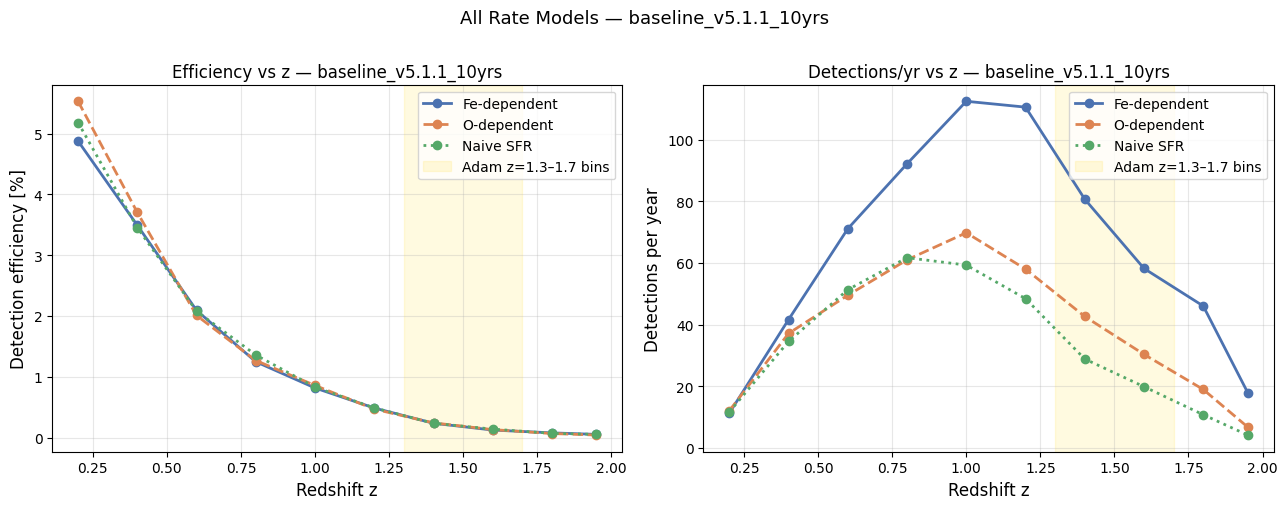

Saved: multimodel_eff_vs_z_four_roll_v5_0_0_10yrs_260407.png


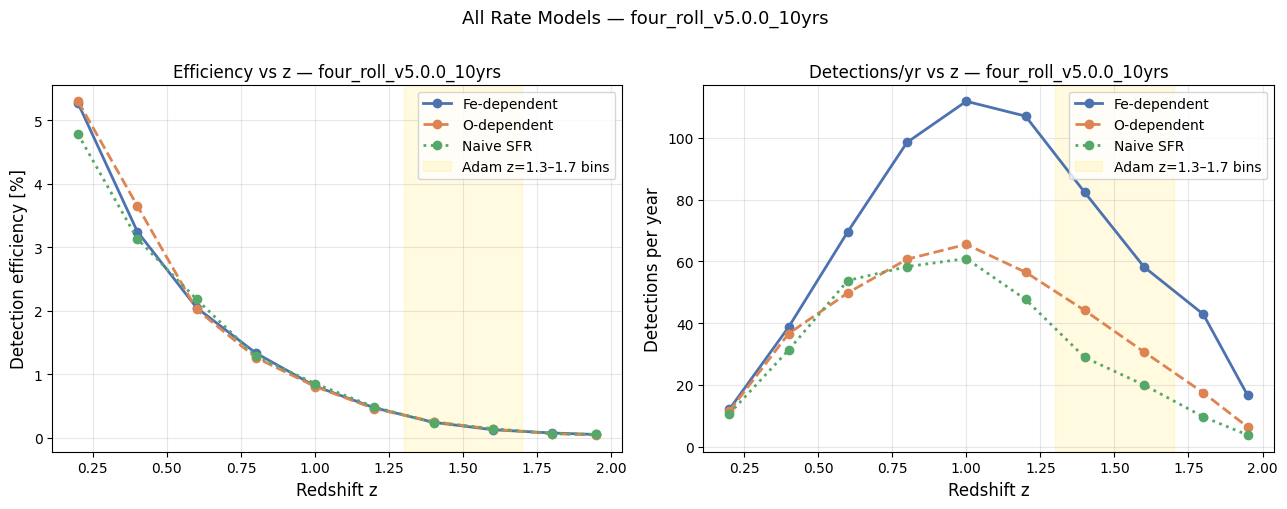

Saved: multimodel_eff_vs_z_noroll_v5_0_0_10yrs_260407.png


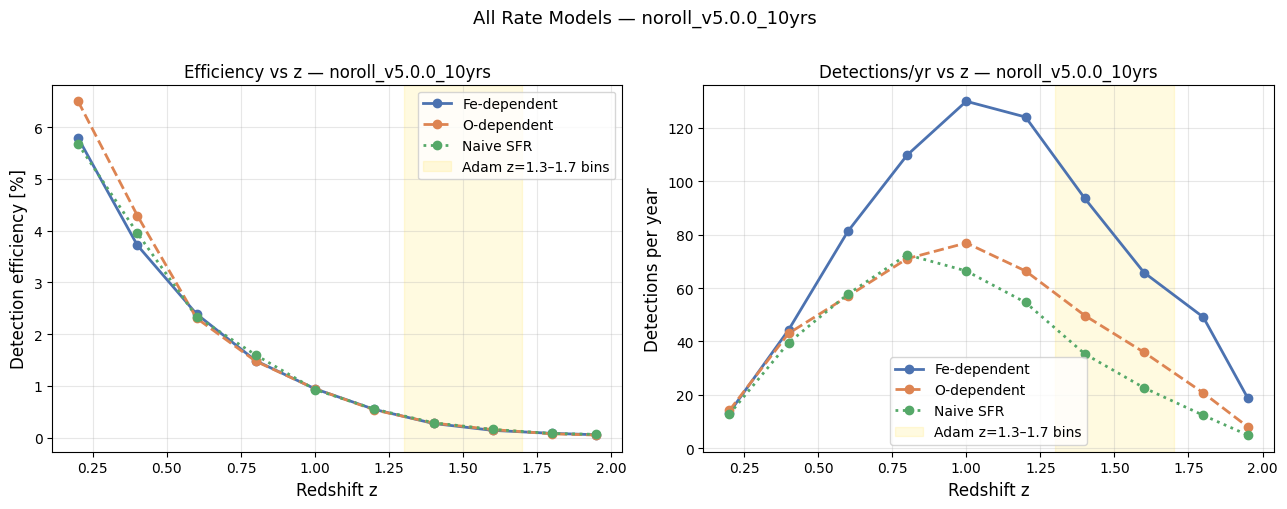

Saved: multimodel_eff_vs_z_poor_weather_v5_0_1_10yrs_260407.png


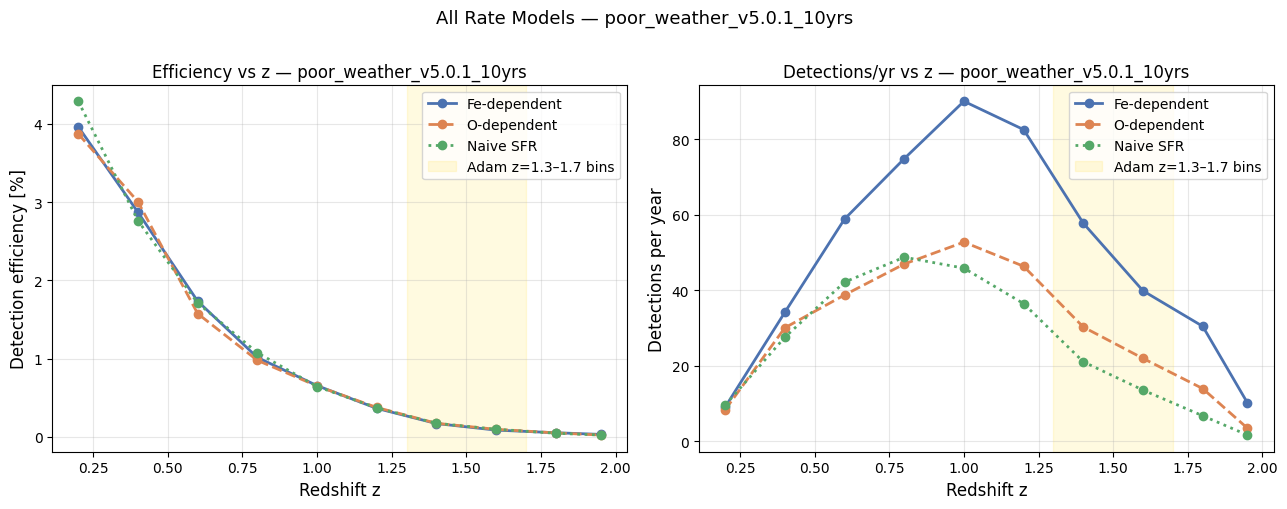

In [7]:
# ============================================================================
# CELL 7: Efficiency vs redshift bin — all 3 models × all cadences
# One figure per cadence: detection efficiency and detections/yr vs z
# ============================================================================

# Redshift bins
z_edges = np.array([0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 1.7, 1.9, 2.0])
z_centers = 0.5 * (z_edges[:-1] + z_edges[1:])

colors_model = {'fe_dependent': '#4C72B0', 'o_dependent': '#DD8452', 'naive': '#55A868'}
ls_model     = {'fe_dependent': '-',       'o_dependent': '--',       'naive': ':'}

for cadence in CADENCES:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for model in MODELS:
        z_m  = pop_data[model]['z']
        vals = pop_data[model]['detect'][cadence]
        if vals is None:
            print(f'  Skipping {model} / {cadence} — no detect array')
            continue

        eff_bins   = []
        count_bins = []
        for z0, z1 in zip(z_edges[:-1], z_edges[1:]):
            mask = (z_m >= z0) & (z_m < z1)
            n_inj = mask.sum()
            n_det = vals[mask].sum()
            eff_bins.append(100 * n_det / n_inj if n_inj > 0 else np.nan)
            count_bins.append(n_det / SURVEY_YEARS)

        label = model_labels[model]
        axes[0].plot(z_centers, eff_bins, marker='o', color=colors_model[model],
                     ls=ls_model[model], lw=2, label=label)
        axes[1].plot(z_centers, count_bins, marker='o', color=colors_model[model],
                     ls=ls_model[model], lw=2, label=label)

    # Adam's bins — shade z=1.3–1.7
    for ax in axes:
        ax.axvspan(1.3, 1.7, alpha=0.12, color='gold', label='Adam z=1.3–1.7 bins')
        ax.set_xlabel('Redshift z', fontsize=12)
        ax.legend(fontsize=10)
        ax.grid(alpha=0.3)

    axes[0].set_ylabel('Detection efficiency [%]', fontsize=12)
    axes[0].set_title(f'Efficiency vs z — {cadence}', fontsize=12)
    axes[1].set_ylabel('Detections per year', fontsize=12)
    axes[1].set_title(f'Detections/yr vs z — {cadence}', fontsize=12)

    cadence_slug = cadence.replace('.', '_')
    plt.suptitle(f'All Rate Models — {cadence}', fontsize=13, y=1.01)
    plt.tight_layout()
    out_fig = get_output_dir('SLSNe') / f'multimodel_eff_vs_z_{cadence_slug}_{DATE_TAG}.png'
    plt.savefig(out_fig, dpi=150, bbox_inches='tight')
    print(f'Saved: {out_fig.name}')
    plt.show()

In [8]:
# ============================================================================
# CELL 8: Adam's fixed-z bins: z=1.2–1.8 and z=1.3–1.7
# All 3 models × all 4 cadences — the primary table Adam requested
# ============================================================================

# Two bin ranges Adam asked about
adam_bins = {
    'z=1.2–1.8': (1.2, 1.8),
    'z=1.3–1.7': (1.3, 1.7),
}

for bin_label, (z_lo, z_hi) in adam_bins.items():
    print(f"\n{'='*65}")
    print(f"Adam's bin: {bin_label}")
    print(f"{'='*65}")
    print(f"{'Model':<16} {'Cadence':<16} {'N injected':>12} "
          f"{'N detected':>12} {'Eff [%]':>9} {'SLSNe/yr':>10}")
    print('-' * 79)

    for model in MODELS:
        z_m = pop_data[model]['z']
        mask_z = (z_m >= z_lo) & (z_m <= z_hi)
        n_inj = mask_z.sum()

        for cadence in CADENCES:
            vals = pop_data[model]['detect'][cadence]
            if vals is None:
                status = 'MISSING'
                print(f'{model:<16} {cadence_labels[cadence]:<16} {n_inj:>12,} {status:>12}')
                continue
            n_det = vals[mask_z].sum()
            eff   = 100 * n_det / n_inj if n_inj > 0 else 0
            per_yr = n_det / SURVEY_YEARS
            print(f'{model_labels[model]:<16} {cadence_labels[cadence]:<16} '
                  f'{n_inj:>12,} {n_det:>12,} {eff:>8.3f}% {per_yr:>9.1f}')
        print()   # blank line between models


Adam's bin: z=1.2–1.8
Model            Cadence            N injected   N detected   Eff [%]   SLSNe/yr
-------------------------------------------------------------------------------
Fe-dependent     baseline            1,224,874        2,178    0.178%     217.8
Fe-dependent     four_roll           1,224,874        2,153    0.176%     215.3
Fe-dependent     noroll              1,224,874        2,435    0.199%     243.5
Fe-dependent     poor_weather        1,224,874        1,518    0.124%     151.8

O-dependent      baseline              612,812        1,130    0.184%     113.0
O-dependent      four_roll             612,812        1,128    0.184%     112.8
O-dependent      noroll                612,812        1,308    0.213%     130.8
O-dependent      poor_weather          612,812          838    0.137%      83.8

Naive SFR        baseline              394,684          759    0.192%      75.9
Naive SFR        four_roll             394,684          757    0.192%      75.7
Naive SFR     

In [9]:
for model in MODELS:
    print(model, list(pop_data[model].keys()))

fe_dependent ['z', 'ra', 'dec', 'peak_time', 'detect', 'characterize', 'spectrigger', 'villar']
o_dependent ['z', 'ra', 'dec', 'peak_time', 'detect', 'characterize', 'spectrigger', 'villar']
naive ['z', 'ra', 'dec', 'peak_time', 'detect', 'characterize', 'spectrigger', 'villar']



--- fe_dependent x baseline_v5.1.1_10yrs ---
  Saved: healpix_detect_fe_dependent_baseline_v5.1.1_10yrs_260407.png
  Saved: healpix_characterize_fe_dependent_baseline_v5.1.1_10yrs_260407.png
  Saved: healpix_spectrigger_fe_dependent_baseline_v5.1.1_10yrs_260407.png


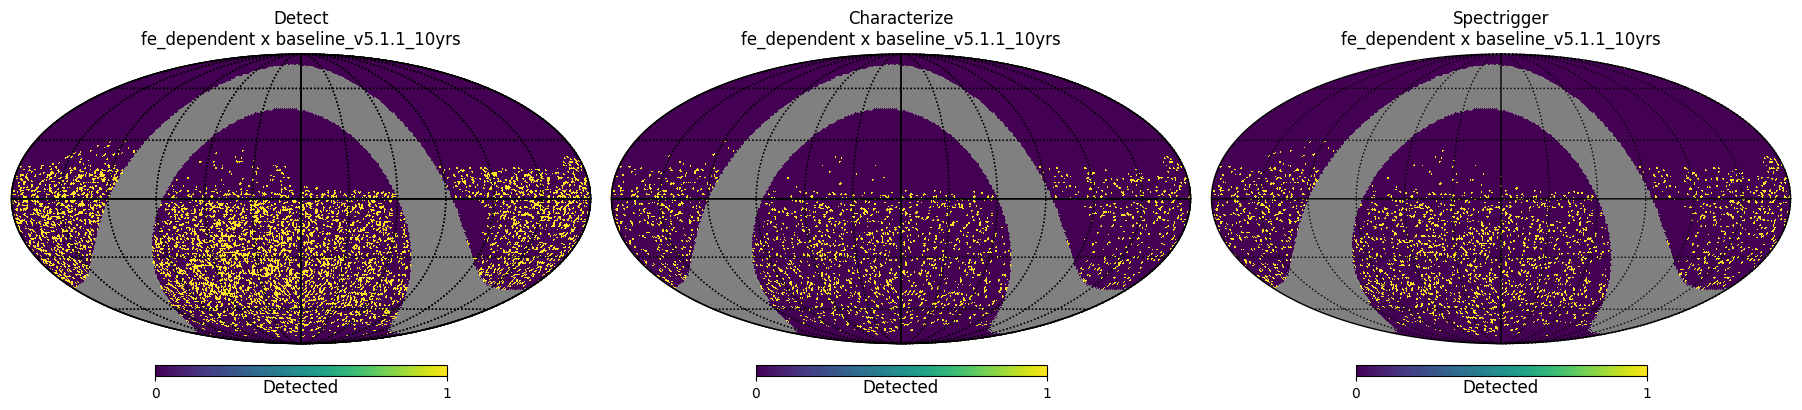

  Saved row: healpix_row_fe_dependent_baseline_v5.1.1_10yrs_260407.png

--- fe_dependent x four_roll_v5.0.0_10yrs ---
  Saved: healpix_detect_fe_dependent_four_roll_v5.0.0_10yrs_260407.png
  Saved: healpix_characterize_fe_dependent_four_roll_v5.0.0_10yrs_260407.png
  Saved: healpix_spectrigger_fe_dependent_four_roll_v5.0.0_10yrs_260407.png


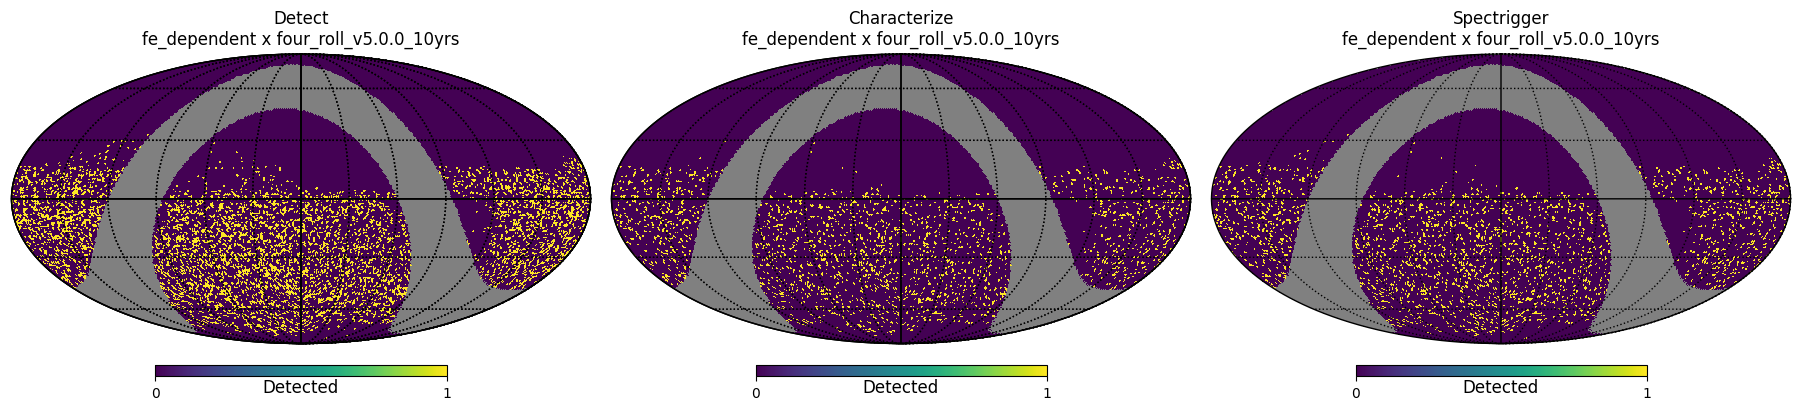

  Saved row: healpix_row_fe_dependent_four_roll_v5.0.0_10yrs_260407.png

--- fe_dependent x noroll_v5.0.0_10yrs ---
  Saved: healpix_detect_fe_dependent_noroll_v5.0.0_10yrs_260407.png
  Saved: healpix_characterize_fe_dependent_noroll_v5.0.0_10yrs_260407.png
  Saved: healpix_spectrigger_fe_dependent_noroll_v5.0.0_10yrs_260407.png


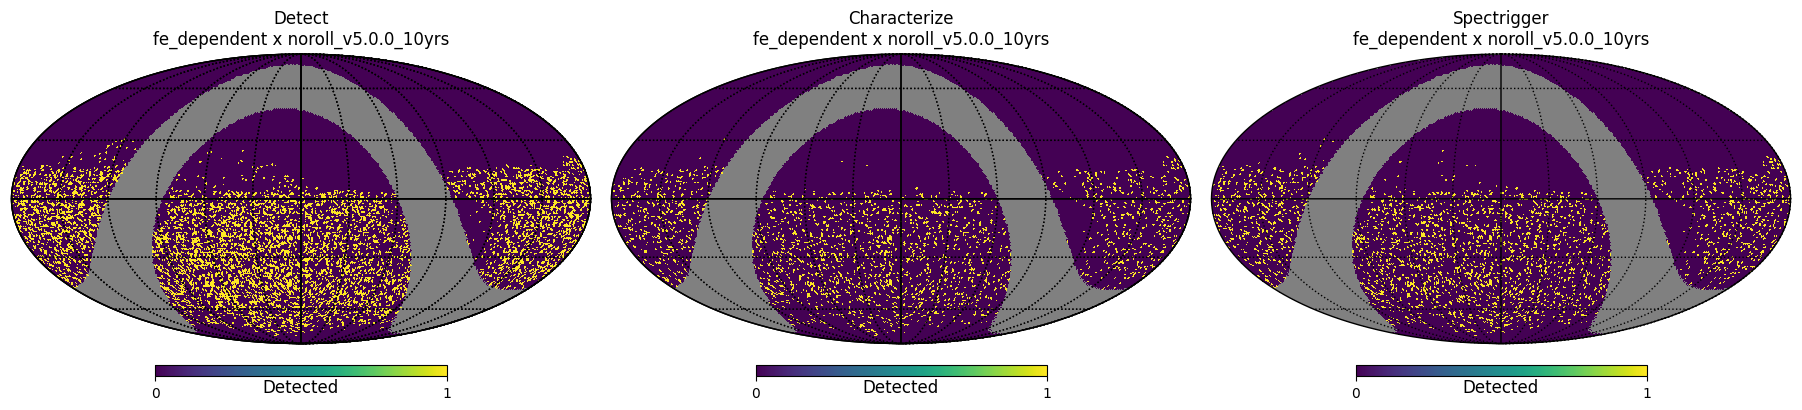

  Saved row: healpix_row_fe_dependent_noroll_v5.0.0_10yrs_260407.png

--- fe_dependent x poor_weather_v5.0.1_10yrs ---
  Saved: healpix_detect_fe_dependent_poor_weather_v5.0.1_10yrs_260407.png
  Saved: healpix_characterize_fe_dependent_poor_weather_v5.0.1_10yrs_260407.png
  Saved: healpix_spectrigger_fe_dependent_poor_weather_v5.0.1_10yrs_260407.png


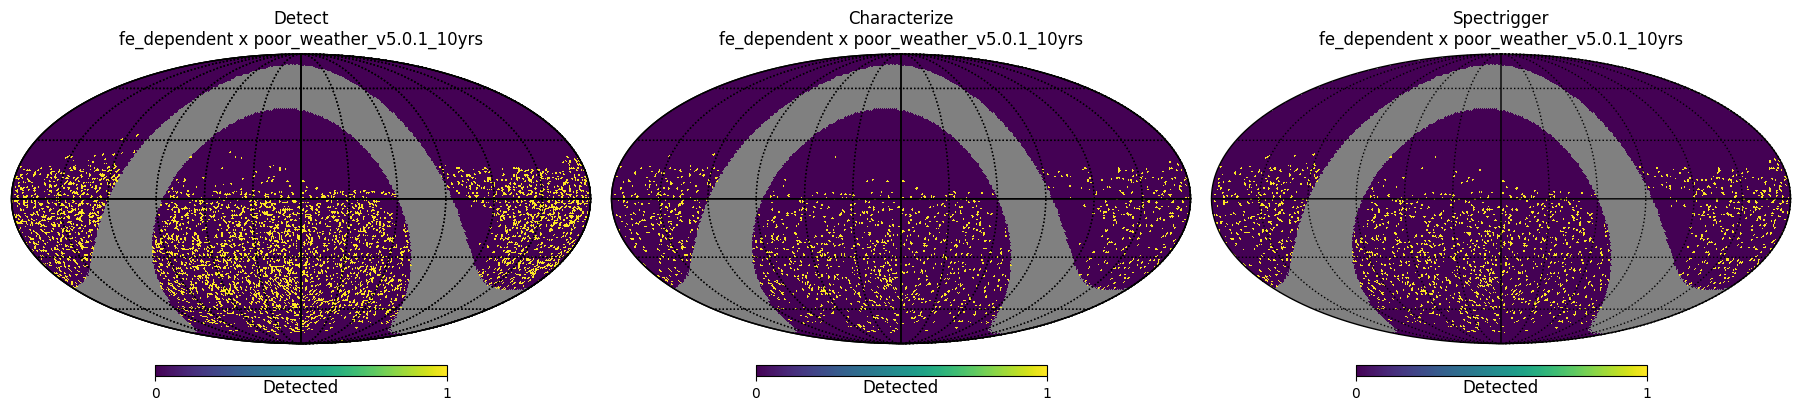

  Saved row: healpix_row_fe_dependent_poor_weather_v5.0.1_10yrs_260407.png

--- o_dependent x baseline_v5.1.1_10yrs ---
  Saved: healpix_detect_o_dependent_baseline_v5.1.1_10yrs_260407.png
  Saved: healpix_characterize_o_dependent_baseline_v5.1.1_10yrs_260407.png
  Saved: healpix_spectrigger_o_dependent_baseline_v5.1.1_10yrs_260407.png


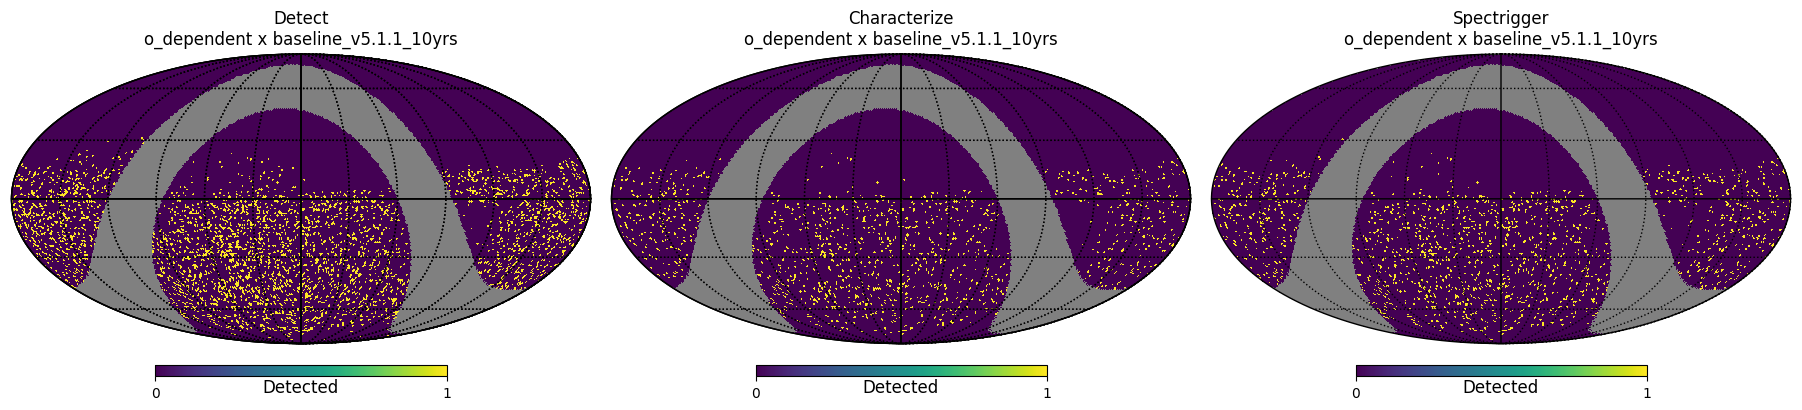

  Saved row: healpix_row_o_dependent_baseline_v5.1.1_10yrs_260407.png

--- o_dependent x four_roll_v5.0.0_10yrs ---
  Saved: healpix_detect_o_dependent_four_roll_v5.0.0_10yrs_260407.png
  Saved: healpix_characterize_o_dependent_four_roll_v5.0.0_10yrs_260407.png
  Saved: healpix_spectrigger_o_dependent_four_roll_v5.0.0_10yrs_260407.png


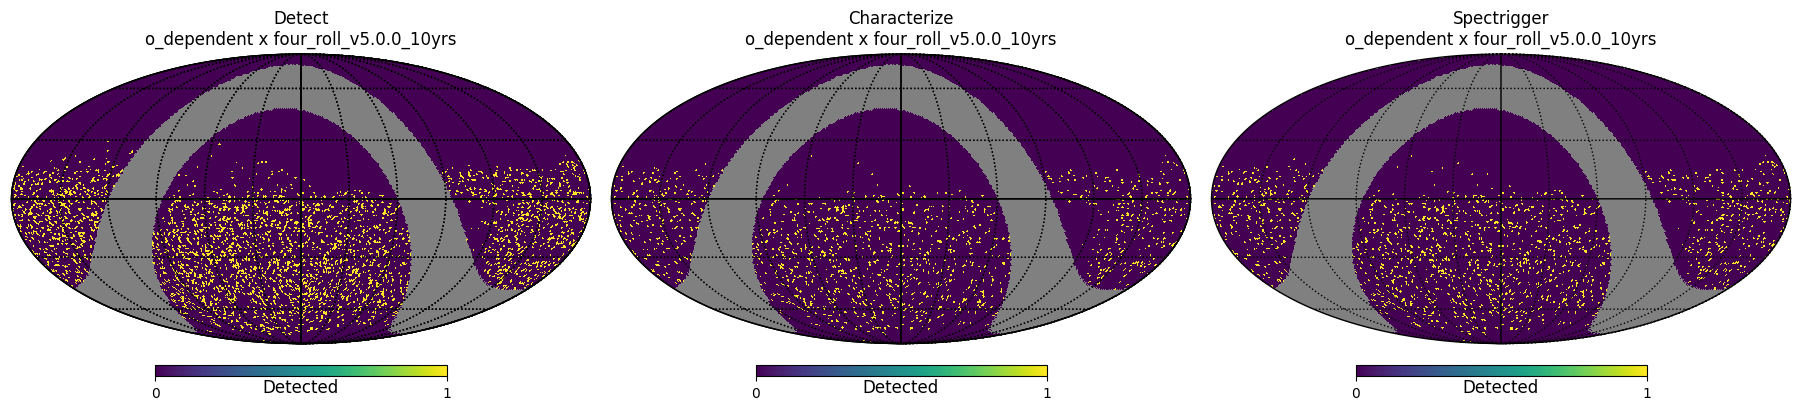

  Saved row: healpix_row_o_dependent_four_roll_v5.0.0_10yrs_260407.png

--- o_dependent x noroll_v5.0.0_10yrs ---
  Saved: healpix_detect_o_dependent_noroll_v5.0.0_10yrs_260407.png
  Saved: healpix_characterize_o_dependent_noroll_v5.0.0_10yrs_260407.png
  Saved: healpix_spectrigger_o_dependent_noroll_v5.0.0_10yrs_260407.png


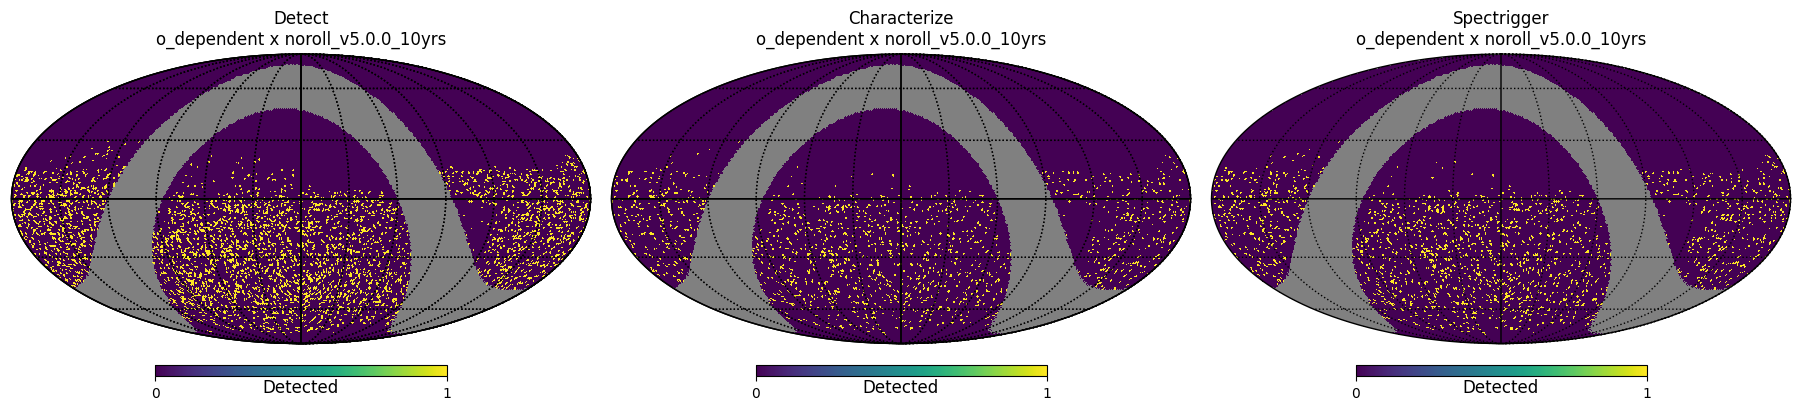

  Saved row: healpix_row_o_dependent_noroll_v5.0.0_10yrs_260407.png

--- o_dependent x poor_weather_v5.0.1_10yrs ---
  Saved: healpix_detect_o_dependent_poor_weather_v5.0.1_10yrs_260407.png
  Saved: healpix_characterize_o_dependent_poor_weather_v5.0.1_10yrs_260407.png
  Saved: healpix_spectrigger_o_dependent_poor_weather_v5.0.1_10yrs_260407.png


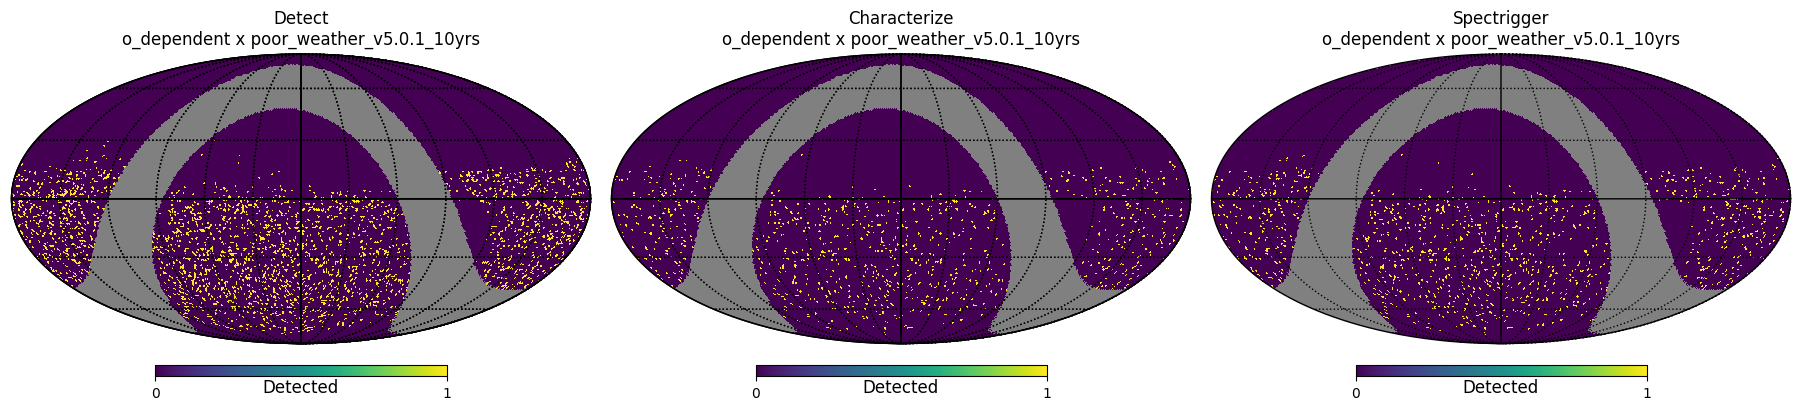

  Saved row: healpix_row_o_dependent_poor_weather_v5.0.1_10yrs_260407.png

--- naive x baseline_v5.1.1_10yrs ---
  Saved: healpix_detect_naive_baseline_v5.1.1_10yrs_260407.png
  Saved: healpix_characterize_naive_baseline_v5.1.1_10yrs_260407.png
  Saved: healpix_spectrigger_naive_baseline_v5.1.1_10yrs_260407.png


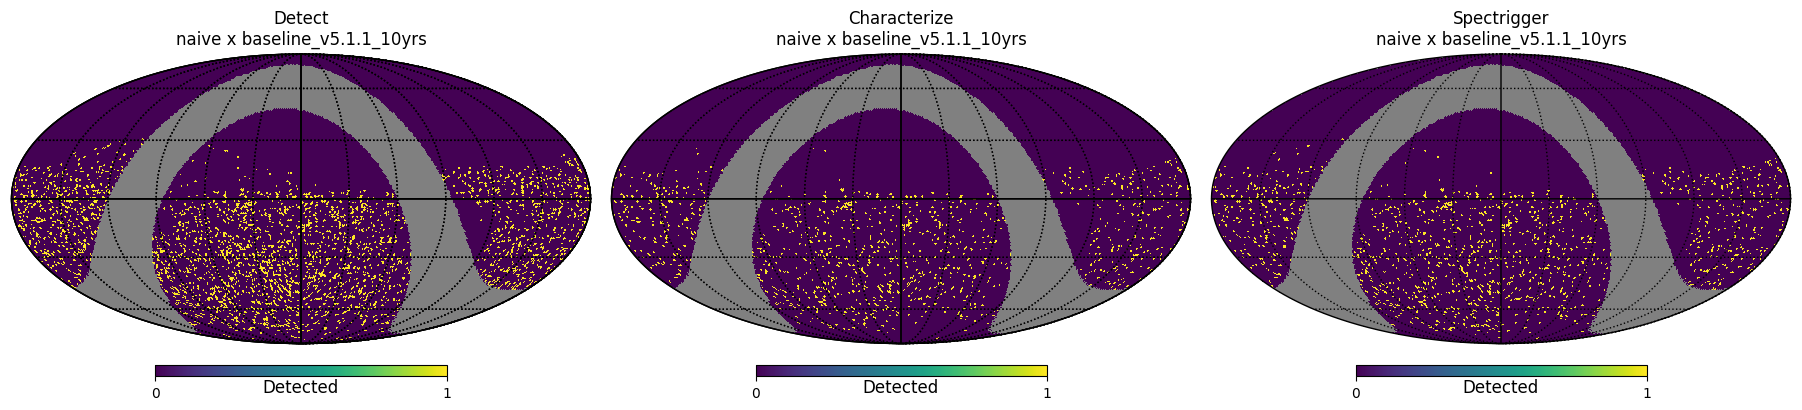

  Saved row: healpix_row_naive_baseline_v5.1.1_10yrs_260407.png

--- naive x four_roll_v5.0.0_10yrs ---
  Saved: healpix_detect_naive_four_roll_v5.0.0_10yrs_260407.png
  Saved: healpix_characterize_naive_four_roll_v5.0.0_10yrs_260407.png
  Saved: healpix_spectrigger_naive_four_roll_v5.0.0_10yrs_260407.png


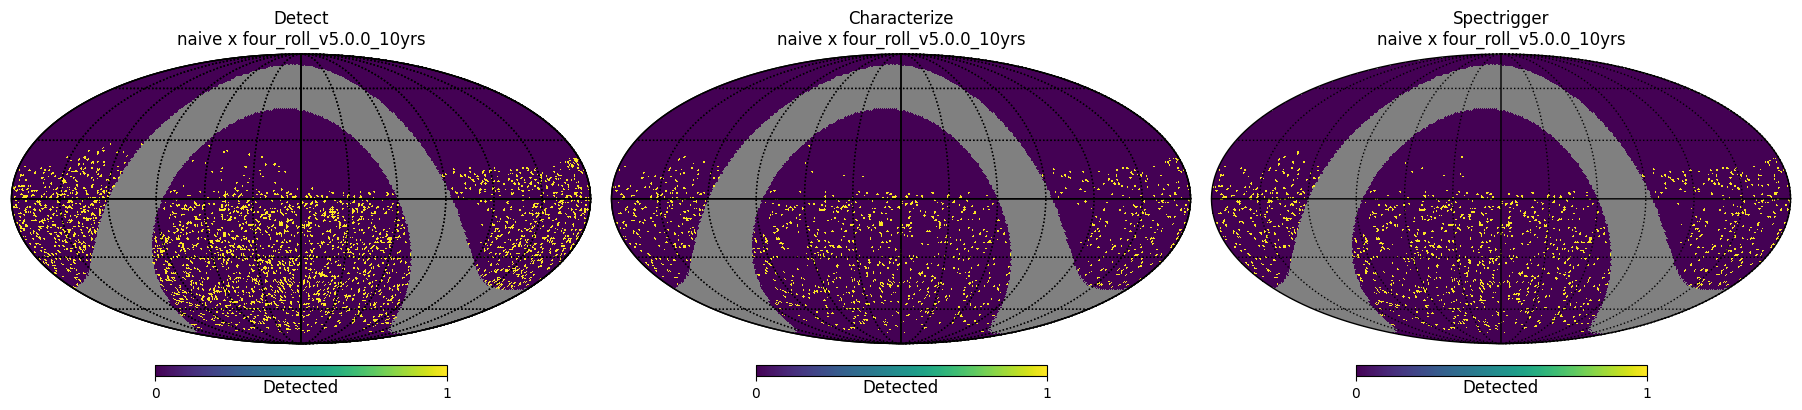

  Saved row: healpix_row_naive_four_roll_v5.0.0_10yrs_260407.png

--- naive x noroll_v5.0.0_10yrs ---
  Saved: healpix_detect_naive_noroll_v5.0.0_10yrs_260407.png
  Saved: healpix_characterize_naive_noroll_v5.0.0_10yrs_260407.png
  Saved: healpix_spectrigger_naive_noroll_v5.0.0_10yrs_260407.png


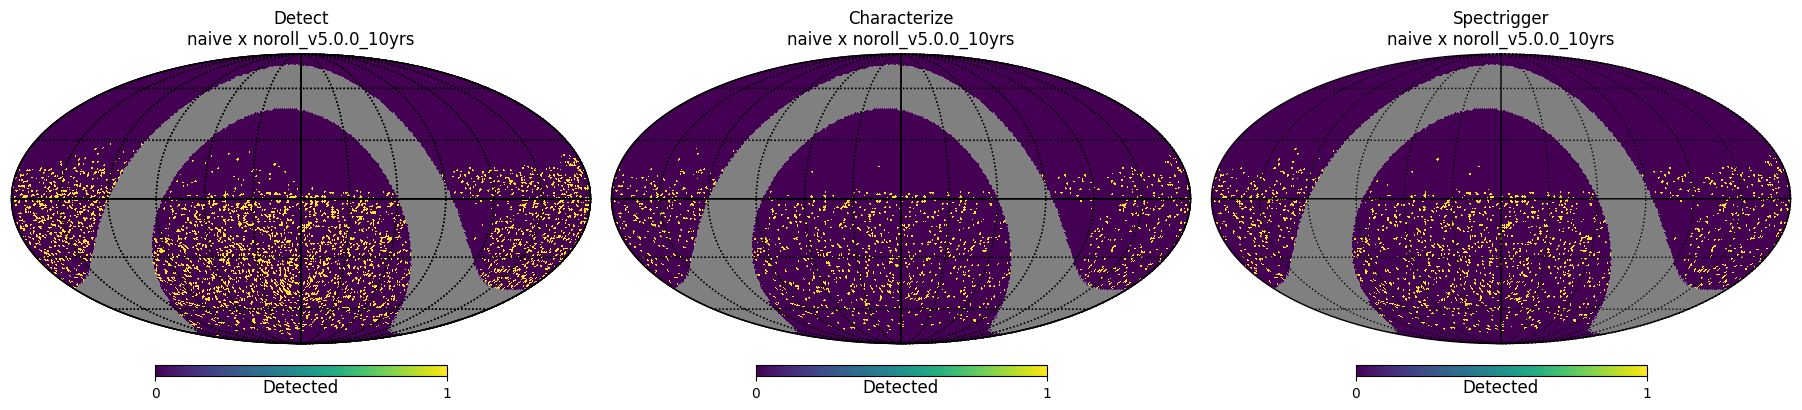

  Saved row: healpix_row_naive_noroll_v5.0.0_10yrs_260407.png

--- naive x poor_weather_v5.0.1_10yrs ---
  Saved: healpix_detect_naive_poor_weather_v5.0.1_10yrs_260407.png
  Saved: healpix_characterize_naive_poor_weather_v5.0.1_10yrs_260407.png
  Saved: healpix_spectrigger_naive_poor_weather_v5.0.1_10yrs_260407.png


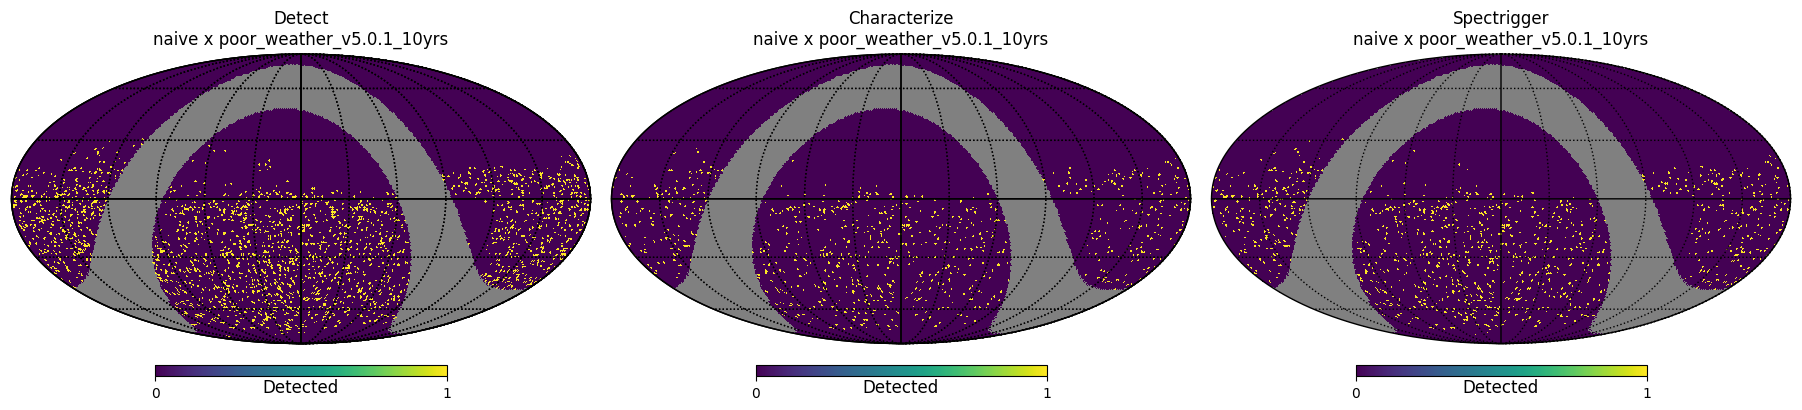

  Saved row: healpix_row_naive_poor_weather_v5.0.1_10yrs_260407.png


In [10]:
# ============================================================================
# CELL 9: HEALPix sky maps — all 3 models × all 4 cadences
# Each cadence = one row of 3 maps (detect, characterize, spectrigger)
# ============================================================================
reload(diag_mod)
from slsn_metrics.diagnostics import plot_healpix_efficiency

METRIC_KEYS = ["detect", "characterize", "spectrigger"]
HEALPIX_FIGSIZE = (18, 4)  # ← width × height per cadence row

for model in MODELS:
    ra_map  = pop_data[model]["ra"]
    dec_map = pop_data[model]["dec"]

    for cadence in CADENCES:
        print(f"\n--- {model} x {cadence} ---")

        # One figure per cadence, 3 subplots side by side
        fig = plt.figure(figsize=HEALPIX_FIGSIZE)

        for col_idx, metric in enumerate(METRIC_KEYS):
            metric_map = pop_data[model][metric][cadence]
            if metric_map is None:
                print(f"  Skipping {metric} — array missing")
                continue

            # Build healpix map
            import healpy as hp
            npix = hp.nside2npix(64)
            injected_map = np.zeros(npix)
            detected_map = np.zeros(npix)
            theta = 0.5 * np.pi - dec_map
            pix   = hp.ang2pix(64, theta, ra_map)
            for i, p in enumerate(pix):
                injected_map[p] += 1
                if int(metric_map[i]) == 1:
                    detected_map[p] += 1
            eff = np.full(npix, hp.UNSEEN)
            mask = injected_map > 0
            eff[mask] = (detected_map[mask] > 0).astype(float)

            # Plot into subplot
            hp.mollview(
                eff,
                title  = f"{metric.capitalize()}\n{model} x {cadence}",
                unit   = 'Detected',
                cmap   = 'viridis',
                min    = 0, max = 1,
                hold   = False,
                sub    = (1, len(METRIC_KEYS), col_idx + 1),
                fig    = fig.number
            )
            hp.graticule()

            # Save individual file too
            out_healpix = get_output_dir("SLSNe", subdir=model) / \
                          f"healpix_{metric}_{model}_{cadence}_{DATE_TAG}.png"
            print(f"  Saved: {out_healpix.name}")

        # Save the combined row figure
        out_row = get_output_dir("SLSNe", subdir=model) / \
                  f"healpix_row_{model}_{cadence}_{DATE_TAG}.png"
        plt.savefig(str(out_row), dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
        print(f"  Saved row: {out_row.name}")


=== baseline_v5.1.1_10yrs | detect ===


/users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/py_files/slsn_metrics/diagnostics.py:2613: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved: mc_panel_detect_baseline_v5.1.1_10yrs.png


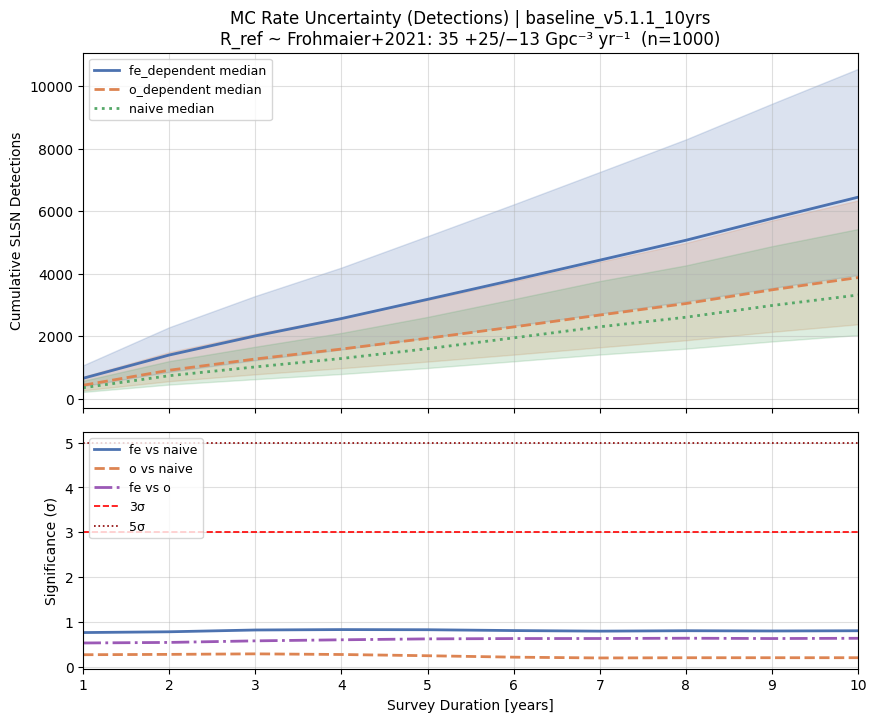


=== four_roll_v5.0.0_10yrs | detect ===
  Saved: mc_panel_detect_four_roll_v5.0.0_10yrs.png


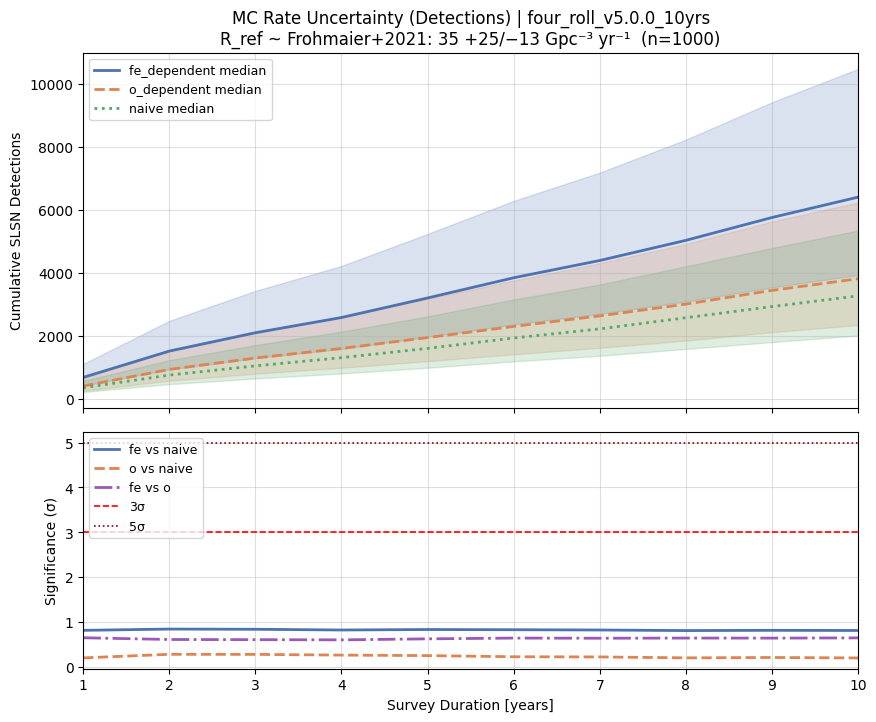


=== noroll_v5.0.0_10yrs | detect ===
  Saved: mc_panel_detect_noroll_v5.0.0_10yrs.png


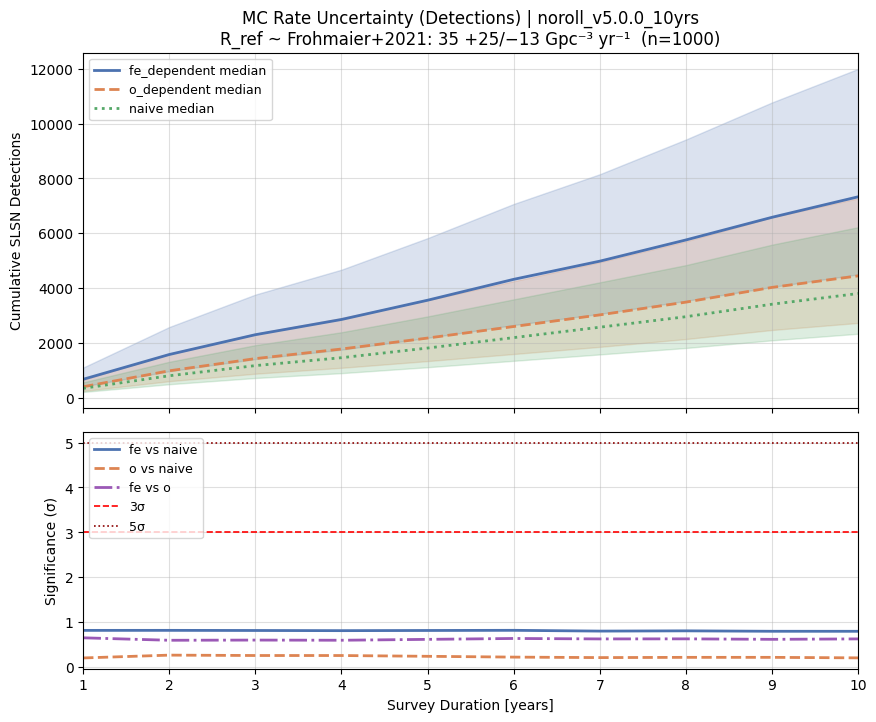


=== poor_weather_v5.0.1_10yrs | detect ===
  Saved: mc_panel_detect_poor_weather_v5.0.1_10yrs.png


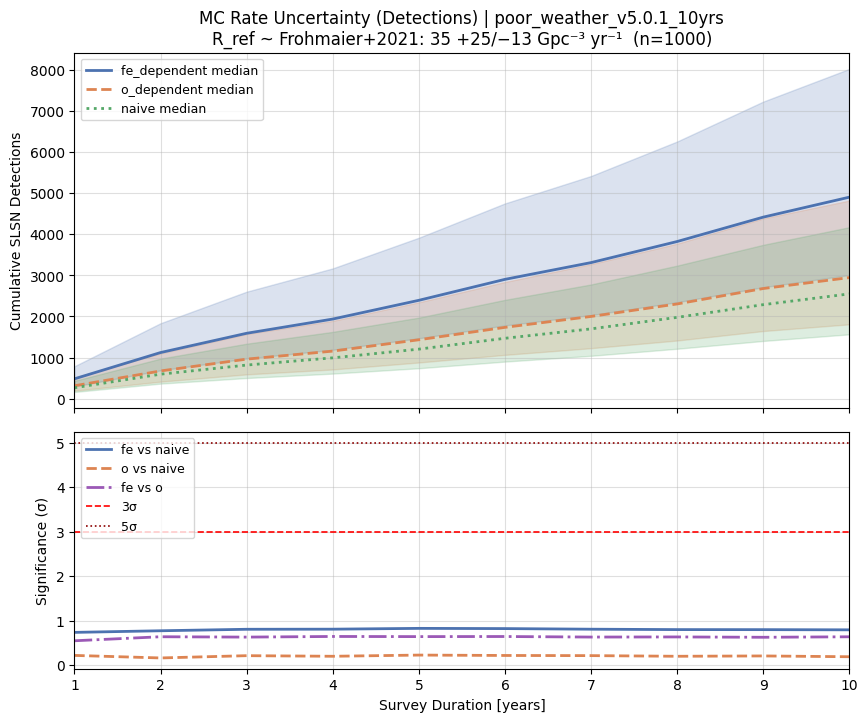

In [13]:
# ============================================================================
# CELL MC: Monte Carlo rate uncertainty — all cadences, all models
# ============================================================================
# Reload flags:
#   Templates  : NO
#   Population : NO — peak_time already in pop_data from Cell 6
#   Mag grid   : NO
#   Kernel     : NO
#
# Toggle METRIC_KEY to switch which detection stage is plotted.
# Produces one figure per cadence, each with:
#   Top    : N(SLSNe) — all 3 models with 68% CI bands
#   Bottom : Significance — fe vs naive, o vs naive, fe vs o
# ============================================================================

import slsn_metrics.diagnostics as diag_mod
from importlib import reload
reload(diag_mod)
from slsn_metrics.diagnostics import plot_mc_rate_uncertainty_panel

# --- Toggle this to switch metric ---
METRIC_KEY   = 'detect'        # options: 'detect', 'characterize', 'spectrigger'
METRIC_LABEL = {
    'detect':       'Detections',
    'characterize': 'Characterized',
    'spectrigger':  'Spec Triggers',
}[METRIC_KEY]

SAVE_DIR = get_output_dir('SLSNe', subdir='fe_dependent')

for cadence in CADENCES:
    print(f'\n=== {cadence} | {METRIC_KEY} ===')
    plot_mc_rate_uncertainty_panel(
        pop_data       = pop_data,
        cadence        = cadence,
        metric_key     = METRIC_KEY,
        metric_label   = METRIC_LABEL,
        R_ref_nominal  = 35.0,
        n_realizations = 1000,
        seed           = 42,
        save_dir       = SAVE_DIR,
    )